# Longer Time Simulation Code

### Since the quantum algorithm solves the harmonic oscillator energies using a Taylor expansion in time, the solution is not valid for high t - small t approximation allows us to ignore higher order terms in the expansion. Thus, we see that the expected kinetic and potential energies blow up with high values of t. However, we can exploit the periodicity of the solution to only evaluate t for a quarter of the oscillator's time period (or half the energy oscillation time period - using swaps).




In [1]:
!pip install -U classiq
!pip install keyrings.alt

  Using cached keyrings.alt-5.0.2-py3-none-any.whl.metadata (3.6 kB)
Using cached keyrings.alt-5.0.2-py3-none-any.whl (17 kB)


In [2]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [3]:
import classiq
classiq.authenticate(overwrite=True)

If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DJSLC-KXDF&scope=offline_access
Your user code: JSLC-KXDF


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from tabulate import tabulate

from classiq import *

In [20]:
# Inputs
n = 2
t_end = 10    # this is the time we want to evolve the system
omega = 1
M = np.array([[0, 1], [-1*omega**2, 0]])
y0 = 1
vy0 = 1
x_0 = [y0, vy0]
b = [0, 0]

# Constants
k = 7
x_0_norm = np.linalg.norm(x_0)
b_norm = np.linalg.norm(b)
M_norm = np.linalg.norm(M, ord=2)
# A = np.multiply(1/np.linalg.norm(M), M)
A = M

In [6]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        c_m[i] = (x_0_norm * (pow(t, i))) / m_factorial
        # c_m[i] = (x_0_norm * (pow(t * M_Norm, i))) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c)

    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(c_m[i]) / c for i in range(k + 1)], e)
    vs1 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [7]:
vs2 = []
d = 0


def VS2():
    global vs2
    global d
    d = 0
    d_m = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
        d += d_m[i - 1]
        n_factorial *= i + 1
    d_m[k] = 0
    d = np.sqrt(d)

    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return
    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(d_m[i]) / d for i in range(k + 1)], e)
    vs2 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [8]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [9]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_x_0 = []
    for i in x_0:
        prob_x_0.append(i / x_0_norm)
    inplace_prepare_amplitudes(prob_x_0, 0.01, x)

    VS1(t)
    VS2()
    V()

    unitary(v, y)
    control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

In [10]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [11]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    ws1 = vs1.conj().T
    ws2 = vs2.conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [12]:
T = int(np.log2(k + 1))  # no of ancilla qubits
dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [13]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### The following cells contain the only differences compared to the quantum harmonic oscillator code in the Classiq library - implements periodicity.

In [23]:
y = []
y_dash = []
t0 = np.pi / omega
dt = t0 / 32       # Convenient to have t0 as a multiple of dt so that all periods have points on the same grid
quarter = t0 / 2
n_steps = int(quarter / dt) if t_end > quarter else int(np.ceil(t_end / dt))

for i in range(n_steps + 1):
    t = i * dt
    print(t)
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))

def expand(t_end, t0, quarter, dt, y_base, ydash_base):
    y_full, ydash_full = [], []
    for i in range(int(t_end / dt) + 1):
        t = i * dt
        t_mod = t % t0
        q_idx = int(t_mod / quarter)
        if q_idx == 0:                        # Q1: direct
            idx = round(t_mod / dt)
            y_full.append(y_base[idx])
            ydash_full.append(ydash_base[idx])
        elif q_idx == 1:                      # Q2: swap only
            s = t_mod - 1 * quarter
            idx = round(s / dt)
            y_full.append(ydash_base[idx])
            ydash_full.append(y_base[idx])
    return y_full, ydash_full

y, y_dash = expand(t_end, t0, quarter, dt, y, y_dash)

0.0
00000  :  1.0000000000000073
00001  :  0.9999999999999913
0.09817477042468103
00000  :  1.0932018670015473
00001  :  0.8971675863424166
0.19634954084936207
00000  :  1.1758756023634023
00001  :  0.7856949583335132
0.2945243112740431
00000  :  1.247225011537847
00001  :  0.666655657120733
0.39269908169872414
00000  :  1.30656295026241
00001  :  0.5411960867545618
0.4908738521234052
00000  :  1.3533179132415152
00001  :  0.4105244486895755
0.5890486225480862
00000  :  1.3870394637583459
00001  :  0.27589904462835074
0.6872233929727672
00000  :  1.4074024163149137
00001  :  0.13861603561030997
0.7853981633974483
00000  :  1.4142096843980365
00001  :  3.2547523211571715e-06
0.8835729338221293
00000  :  1.4073937054693513
00001  :  0.1386254049896255
0.9817477042468103
00000  :  1.3870163552771526
00001  :  0.27591824053741526
1.0799224746714913
00000  :  1.3532672635878555
00001  :  0.4105643706477443
1.1780972450961724
00000  :  1.306460443435149
00001  :  0.5412748295438429
1.2762720

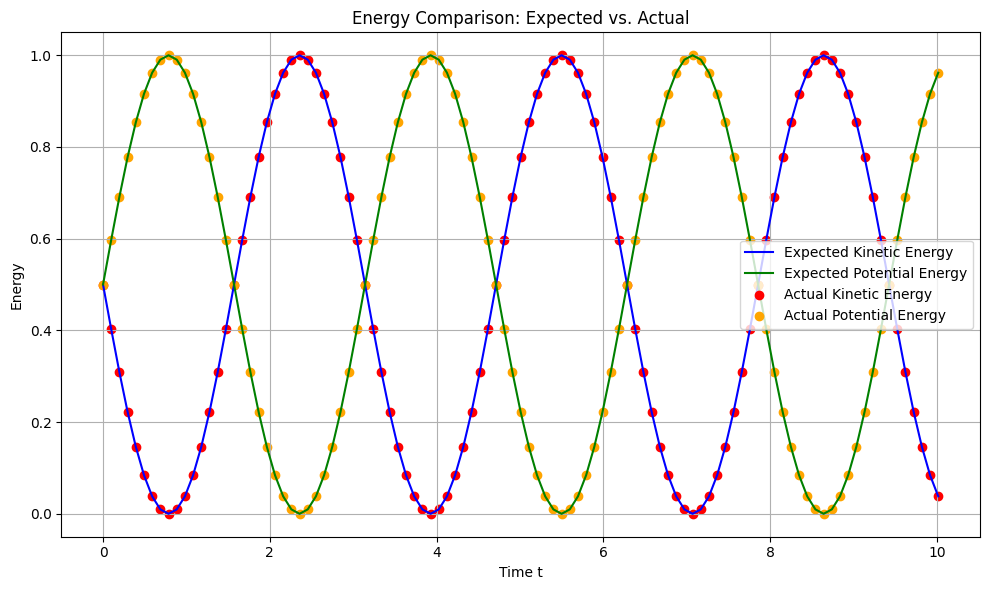

In [24]:
t_values = [i * dt for i in range(round(t_end / dt) + 1)]
def lookup(t, base):
    idx = round((t % t0) / dt)
    return base[idx]

y1      = [lookup(t, y)      for t in t_values]
y_dash1 = [lookup(t, y_dash) for t in t_values]

A0 = vy0/omega
B0 = y0

# Expected energies calculated from the formulas
y_values = [A0 * np.sin(t) + B0 * np.cos(t) for t in t_values]
ydash_values = [A0 * omega * np.cos(t) - B0 * omega * np.sin(t) for t in t_values]

kinetic_expected = [(ydash**2) / 2 for ydash in ydash_values]
potential_expected = [(omega**2) * (y**2) / 2 for y in y_values]


# Actual energies calculated from algorithm outputs:
kinetic_actual = [(ydash_val**2) / 2 for ydash_val in y_dash1]
potential_actual = [(omega**2) *(y_val**2) / 2 for y_val in y1]


plt.figure(figsize=(10, 6))


plt.plot(
    t_values,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values, kinetic_actual, label="Actual Kinetic Energy", color="red", marker="o"
)
plt.scatter(
    t_values,
    potential_actual,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.title("Energy Comparison: Expected vs. Actual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
results = [
    [
        i * dt,
        kinetic_expected[i],
        kinetic_actual[i],
        potential_expected[i],
        potential_actual[i],
    ]
    for i in range(round(t_end / dt) + 1)
]
table = tabulate(
    results,
    headers=[
        "t",
        "Kinetic expected",
        "Kinetic actual",
        "Potential expected",
        "Potential actual)",
    ],
    numalign="center",
    tablefmt="github",
)
print(table)

error_bound_potential = [
    100 * np.abs(a - e) / a for a, e in zip(potential_expected, potential_actual)
    if a > 1e-6
]
error_bound_kinetic = [
    100 * np.abs(a - e) / a for a, e in zip(kinetic_expected, kinetic_actual)
    if a > 1e-6
]

print("\n\nkinetic accuracy (Mean): ", 100 - np.mean(error_bound_kinetic), "%")
print("potential accuracy (Mean): ", 100 - np.mean(error_bound_potential), "%")

|     t     |  Kinetic expected  |  Kinetic actual  |  Potential expected  |  Potential actual)  |
|-----------|--------------------|------------------|----------------------|---------------------|
|     0     |        0.5         |       0.5        |         0.5          |         0.5         |
| 0.0981748 |      0.402455      |     0.402455     |       0.597545       |      0.597545       |
|  0.19635  |      0.308658      |     0.308658     |       0.691342       |      0.691342       |
| 0.294524  |      0.222215      |     0.222215     |       0.777785       |      0.777785       |
| 0.392699  |      0.146447      |     0.146447     |       0.853553       |      0.853553       |
| 0.490874  |     0.0842652      |    0.0842652     |       0.915735       |      0.915735       |
| 0.589049  |     0.0380602      |    0.0380601     |       0.96194        |      0.961939       |
| 0.687223  |     0.00960736     |    0.0096072     |       0.990393       |      0.990391       |
| 0.785398

### Just for comparison, here is what the plot looks like without using periodicity:

In [26]:
y_og = []
y_dash_og = []
dt_og = 0.1
n_steps_og = int(t_end / dt_og)

for i in range(n_steps_og + 1):
    t_og = i * dt_og
    print(t_og)
    qmod_og = create_model(create_main_for_t(t_og))
    qmod_og = set_execution_preferences(qmod_og, execution_preferences)
    qprog_og = synthesize(qmod_og)
    job_og = execute(qprog_og)
    results_og = job_og.result_value()
    for j in results_og.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y_og.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash_og.append(np.linalg.norm(j.amplitude) * (N * N))

0.0
00000  :  1.0000000000000073
00001  :  0.9999999999999913
0.1
00000  :  1.0948375819246106
00001  :  0.8951707486309338
0.2
00000  :  1.1787359085714353
00001  :  0.7813972469841067
0.30000000000000004
00000  :  1.2508566941071477
00001  :  0.6598162808928283
0.4
00000  :  1.3104793193650874
00001  :  0.5316426361904842
0.5
00000  :  1.3570079985119132
00001  :  0.39815693204363456
0.6000000000000001
00000  :  1.3899776457142847
00001  :  0.260692754285675
0.7000000000000001
00000  :  1.4090583418055667
00001  :  0.12062318874998944
0.8
00000  :  1.414058300952389
00001  :  0.020653145396827683
0.9
00000  :  1.4049252373214431
00001  :  0.16172646232141877
1.0
00000  :  1.3817460317460477
00001  :  0.30119047619046857
1.1
00000  :  1.3447445983928699
00001  :  0.43765726783731573
1.2000000000000002
00000  :  1.2942778514285755
00001  :  0.569772251428578
1.3
00000  :  1.2308296716865583
00001  :  0.6962291411309584
1.4000000000000001
00000  :  1.1550027733333135
00001  :  0.8157848

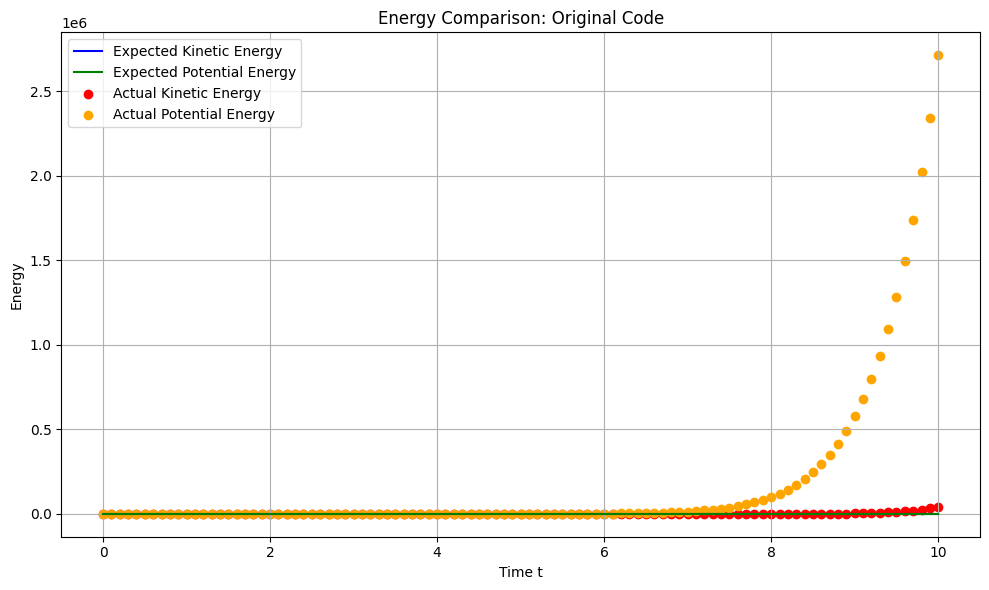

In [36]:
t_values_og = [i * dt_og for i in range(round(t_end / dt_og) + 1)]

A0 = vy0/omega
B0 = y0

# Expected energies calculated from the formulas
y_values = [A0 * np.sin(t) + B0 * np.cos(t) for t in t_values_og]
ydash_values = [A0 * omega * np.cos(t) - B0 * omega * np.sin(t) for t in t_values_og]

kinetic_expected = [(ydash**2) / 2 for ydash in ydash_values]
potential_expected = [(omega**2) * (y**2) / 2 for y in y_values]

# Actual energies calculated from algorithm outputs:
kinetic_actual_og = [(ydash_val**2) / 2 for ydash_val in y_dash_og]
potential_actual_og = [(omega**2) * (y_val**2) / 2 for y_val in y_og]

plt.figure(figsize=(10, 6))


plt.plot(
    t_values_og,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values_og,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values_og,
    kinetic_actual_og,
    label="Actual Kinetic Energy",
    color="red",
    marker="o"
)


plt.scatter(
    t_values_og,
    potential_actual_og,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.title("Energy Comparison: Original Code")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

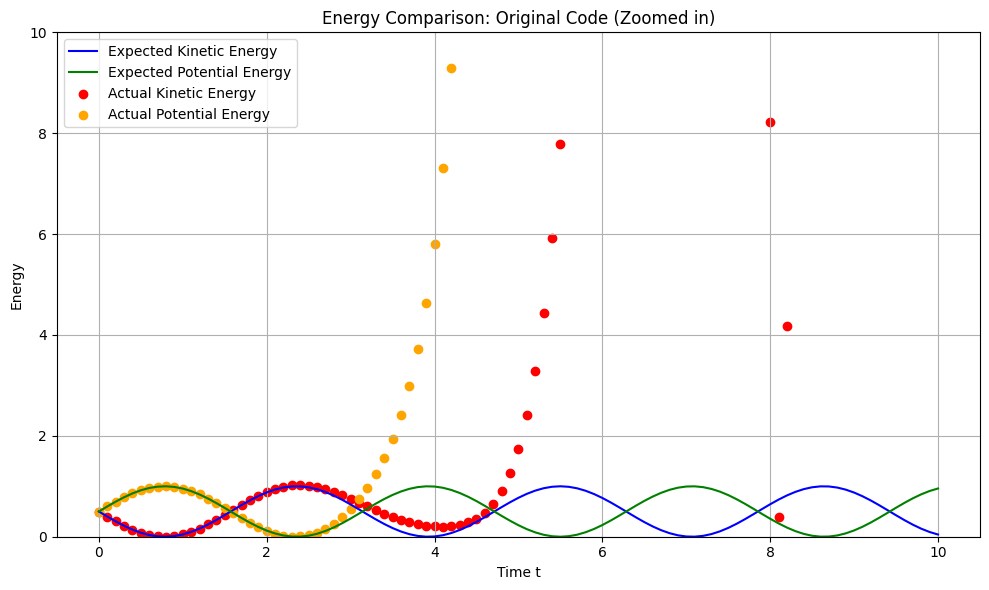

In [37]:
plt.figure(figsize=(10, 6))


plt.plot(
    t_values_og,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values_og,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values_og,
    kinetic_actual_og,
    label="Actual Kinetic Energy",
    color="red",
    marker="o"
)


plt.scatter(
    t_values_og,
    potential_actual_og,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.ylim(0,10)
plt.title("Energy Comparison: Original Code (Zoomed in)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()